Tested with:
- Python 3.13.9
- numpy 2.4.4
- pandas 2.3.3
- scikit-learn 1.7.2
- rdkit 2026.3.1
- modAL 0.4.2.1
- schnetpack 2.2.0
- ase 3.26.0
- torch 2.6.0+cu124
- torch_geometric 2.7.0
- scikit-activeml 1.0.0
- skorch 1.3.1

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pprint  # Pretty print data structures
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import random
from rdkit import Chem
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
plt.style.use('ggplot')  # Set Matplotlib style to 'ggplot'

# Set seed for reproducibility
import os
import torch

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
def seed_set(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_set(42)
torch.use_deterministic_algorithms(True)
generator = torch.Generator().manual_seed(42)

In [16]:
# --- Training and Evaluation Functions ---
import torch.nn.functional as F
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
target_idx = 4 # 'gap' in list ['mu', 'alpha', 'homo', 'lumo', 'gap', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv']

def train(loader, model):
    '''
    Train the model for one epoch on loader.

    Optimizes using MSE loss, and reports RMSE, MAE, and MSE
    
    Args:
        loader: Data loader yielding batched graph data.
        model: Model that takes `(data.z, data.pos, data.batch)` as input.

    Returns: 
        tuple: `(rmse, mae, mse, r2)` for the epoch, or
        `(nan, nan, nan, nan)` if no valid samples are processed.
    '''
    model.train()
    total_loss = total_mae = total_samples = 0
    y_pred, y_true = [], []
    for data in loader:
        data = data.to(device)
        true = data.y.view(data.num_graphs, -1)[:, target_idx]
        if torch.isnan(true).any() or torch.isinf(true).any():
            continue
        
        pred = model(data.z, data.pos, data.batch).squeeze(-1)
        if torch.isnan(pred).any() or torch.isinf(pred).any():
            continue
        
        optimizer.zero_grad()
        mse_loss = F.mse_loss(pred, true)
        mae_loss = F.l1_loss(pred, true)
        mse_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += mse_loss.item() * data.num_graphs
        total_mae += mae_loss.item() * data.num_graphs
        total_samples += data.num_graphs
        
        y_pred.append(pred.detach().cpu())
        y_true.append(true.detach().cpu())
    y_pred = torch.cat(y_pred).numpy()
    y_true = torch.cat(y_true).numpy()
    
    if total_samples == 0:
        return float('nan'), float('nan'), float('nan'), float('nan')
    
    rmse = np.sqrt(total_loss/total_samples)
    mae = total_mae/total_samples
    mse = total_loss/total_samples
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, mse, r2

@torch.no_grad()
def evaluate(loader, model):
    '''
    Evaluate model on loader and compute regression metrics.

    Args:
        loader: Data loader yielding batched graph data.
        model: Model that takes `(data.z, data.pos, data.batch)` as input.

    Returns:
        tuple: `(rmse, mae, mse, r2, y_true, y_pred)`, where `y_true` and
        `y_pred` are NumPy arrays containing the true and predicted values.
    '''
    model.eval()
    y_pred, y_true = [], []
    for data in loader:
        data = data.to(device)
        true = data.y.view(data.num_graphs, -1)[:, target_idx]
        pred = model(data.z, data.pos, data.batch).squeeze(-1)
        y_pred.append(pred.cpu().numpy())
        y_true.append(true.cpu().numpy())
    y_pred = np.concatenate(y_pred)
    y_true = np.concatenate(y_true)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, mse, r2, y_true, y_pred

@torch.no_grad()
def plot_prediction(loader, model, model_name=None, name='gap', figsize=(6, 6), save=None, format='pdf'):
    '''
    Plot predicted vs. true values for model on loader.

    Computes evaluation metrics, displays a scatter plot of true versus
    predicted values with a reference diagonal, and prints MAE, MSE, RMSE,
    and R^2.

    Args:
        loader: Data loader yielding batched graph data (torch_geometric.loader.DataLoader).
        model: Fitted model (torch compatible model).
        model_name: Name of the model (str).
        name: Name of the target value (str). 
        figsize: Figure size (tuple).
        save: Save path (str).
        format: Save format (str).
    '''
    rmse, mae, mse, r2, y_true, y_pred = evaluate(loader, model)
    errors = np.abs(y_true - y_pred)
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(y_true, y_pred, c=errors, cmap='viridis')
    ax.plot(y_true, y_true, 'r-')
    ax.set_xlabel(f'true {name}')
    ax.set_ylabel(f'predicted {name}')
    if model_name is None:
        ax.set_title(f'{name} {model.__class__.__name__} prediction plot')
    else:
        ax.set_title(f'{name} {model_name} prediction plot')
    
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()
    print('Training scores:')
    print(f'MAE = {mae:.4f}')
    print(f'MSE = {mse:.4f}') 
    print(f'RMSE = {rmse:.4f}')
    print(f'r^2 = {r2:.4f}')

In [18]:
# Draw 3D structure of a molecule
import py3Dmol
from ase import Atoms
from ase.io import write
from io import StringIO


def show_ase_atoms_3d(atoms, width=500, height=400):
    buf = StringIO()
    write(buf, atoms, format="xyz")
    xyz = buf.getvalue()

    view = py3Dmol.view(width=width, height=height)
    view.addModel(xyz, "xyz")
    view.setStyle(
        {
            "stick": {"radius": 0.15},
            "sphere": {"scale": 0.28},
        }
    )
    view.zoomTo()
    return view.show()

dataset = torch.load('../data/qm9/qm9.pt', weights_only=False)
entry = dataset[4809]
atoms = Atoms(numbers=entry.z, positions=entry.pos)
show_ase_atoms_3d(atoms)
print(f'gap = {entry.y[4]:.4f} Ha')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

gap = 0.2199 Ha


### Load dataset

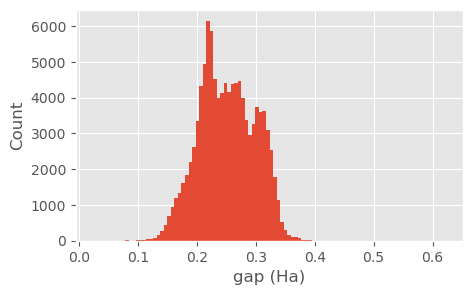

Min gap: 0.0246 Ha
Max gap: 0.6221 Ha


In [46]:
# Plot train histogram
train_gaps = np.array(
    [float(data.y.detach().cpu().view(-1)[target_idx]) for data in train_data],
    dtype=float,
)
plt.figure(figsize=(5, 3))
plt.hist(train_gaps, bins=100)
plt.xlabel('gap (Ha)')
plt.ylabel("Count")
plt.show()
print(f'Min gap: {train_gaps.min():.4f} Ha')
print(f'Max gap: {train_gaps.max():.4f} Ha')

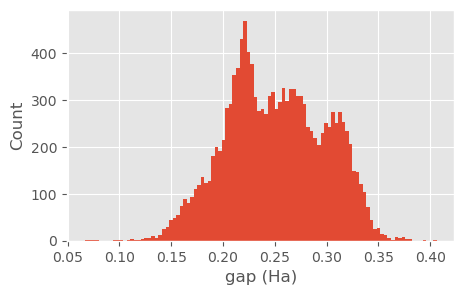

Min gap: 0.0663 Ha
Max gap: 0.4063 Ha


In [47]:
# Plot test histogram
test_gaps = np.array(
    [float(data.y.detach().cpu().view(-1)[target_idx]) for data in test_data],
    dtype=float,
)
plt.figure(figsize=(5, 3))
plt.hist(test_gaps, bins=100)
plt.xlabel('gap (Ha)')
plt.ylabel("Count")
plt.show()
print(f'Min gap: {test_gaps.min():.4f} Ha')
print(f'Max gap: {test_gaps.max():.4f} Ha')

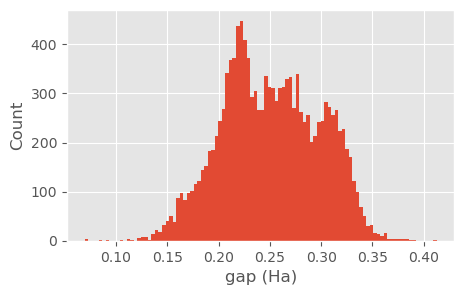

Min gap: 0.0692 Ha
Max gap: 0.4128 Ha


In [48]:
# Plot val histogram
val_gaps = np.array(
    [float(data.y.detach().cpu().view(-1)[target_idx]) for data in val_data],
    dtype=float,
)
plt.figure(figsize=(5, 3))
plt.hist(val_gaps, bins=100)
plt.xlabel('gap (Ha)')
plt.ylabel("Count")
plt.show()
print(f'Min gap: {val_gaps.min():.4f} Ha')
print(f'Max gap: {val_gaps.max():.4f} Ha')

In [3]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

train_dataset = torch.load('../data/qm9/gap/qm9_gap_train.pt', weights_only=False)
test_dataset = torch.load('../data/qm9/gap/qm9_gap_test.pt', weights_only=False)
val_dataset = torch.load('../data/qm9/gap/qm9_gap_val.pt', weights_only=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=generator)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [41]:
print(train_dataset[0].y)

tensor([ 2.8747e+00,  6.7470e+01, -2.3050e-01,  7.2300e-02,  3.0280e-01,
         1.4304e-01, -3.6379e+02, -3.6378e+02, -3.6378e+02, -3.6382e+02,
         2.6139e+01])


## Schnet

### Training

In [5]:
from torch_geometric.nn import SchNet
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Create a config dictionary
config = {
    'hidden_channels': 64,
    'num_filters': 256,
    'num_interactions': 6,
    'num_gaussians': 50,
    'cutoff': 6.0,
    'target_idx': 4, # 'gap'
    'readout' : 'add',
}

# Define model
model = SchNet(
    hidden_channels=config['hidden_channels'],
    num_filters=config['num_filters'],
    num_interactions=config['num_interactions'],
    num_gaussians=config['num_gaussians'],
    cutoff=config['cutoff'],
    readout=config['readout'],
).to(device)

# Define optimizer
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

# Training Loop
os.makedirs('models', exist_ok=True)
epochs=500
counter=0
early_stopping=20

best_rmse = float('inf')
history = {'train_rmse': [], 'train_mae': [], 'train_mse': [], 'test_rmse': [], 'test_mae': [], 'test_mse': [], 'test_r2': []}

epoch_bar = tqdm(range(epochs), desc='Training', unit='epoch', ncols=150)
for epoch in epoch_bar:
    train_rmse, train_mae, train_mse, train_r2 = train(train_loader, model)
    test_rmse, test_mae, test_mse, test_r2, test_y_true, test_y_pred  = evaluate(test_loader, model)
    
    scheduler.step(test_mse)

    # Track history
    history['train_rmse'].append(train_rmse)
    history['train_mae'].append(train_mae)
    history['train_mse'].append(train_mse)
    history['test_rmse'].append(test_rmse)
    history['test_mae'].append(test_mae)
    history['test_mse'].append(test_mse)
    history['test_r2'].append(test_r2)

    # Save best model
    if test_rmse < best_rmse:
        best_rmse = test_rmse
        counter=0
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': config
        }, 'models/schnet/schnet_gap_qm9_2.pt')
    else:
        counter+=1

    epoch_bar.set_postfix(
        train_rmse=f'{train_rmse:.4f}',
        test_rmse=f'{test_rmse:.4f}',
        best_rmse=f'{best_rmse:.4f}',
        lr=f'{optimizer.param_groups[0]['lr']:.1e}',
        paitence_counter=f'{counter}/{early_stopping}'
    )
    
    if counter >= early_stopping:
            print('Early stopping triggered.')
            break    
print(f'Best test RMSE: {best_rmse:.4f}')

df = pd.DataFrame(history)
df.to_csv('models/schnet/history_schnet_gap_qm9_2.csv', index=False)

Training: 100%|████| 500/500 [33:02:19<00:00, 237.88s/epoch, best_rmse=0.0059, lr=1.0e-06, paitence_counter=9/20, test_rmse=0.0060, train_rmse=0.0052]

Best test RMSE: 0.0059


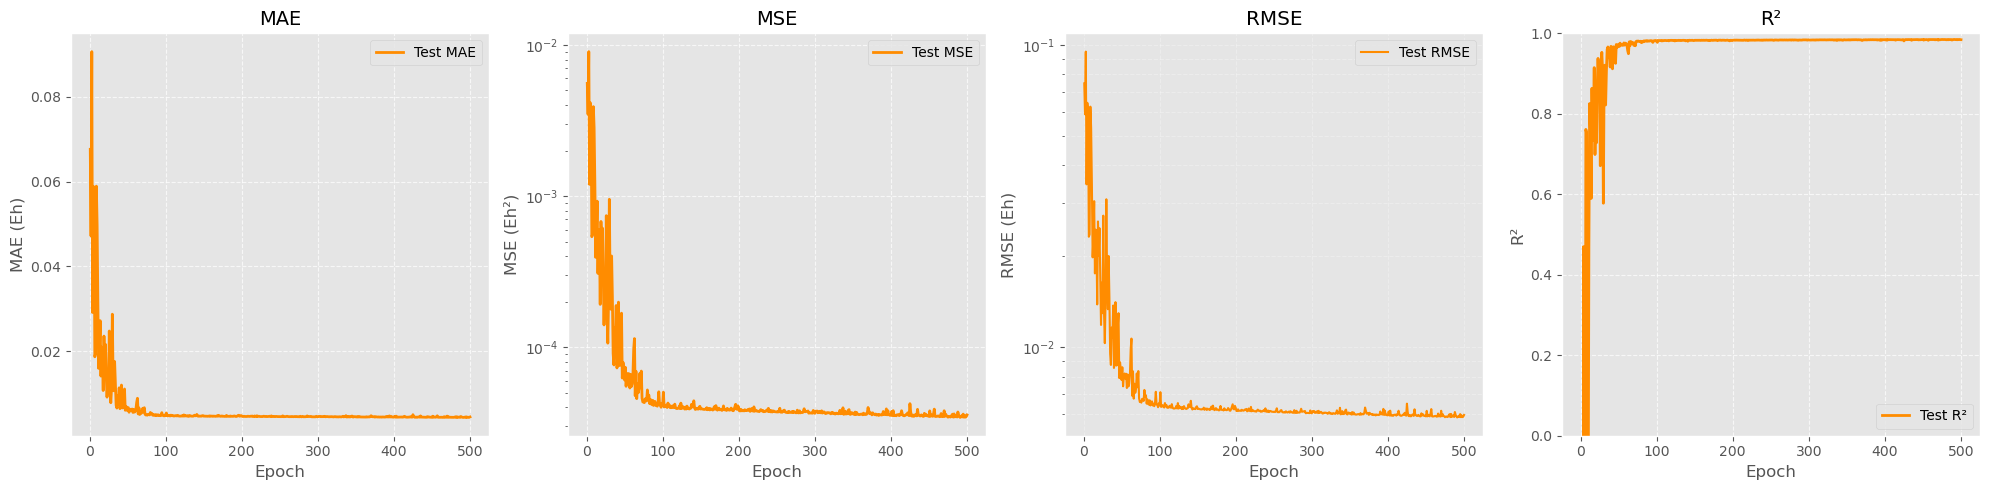

In [12]:
import matplotlib.pyplot as plt

def plot_history(history, save=None, format='pdf'):
    epochs = range(1, len(history['train_mae']) + 1)
    
    # Create a figure with two side-by-side plots
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))

    # --- Plot 1: MAE (Mean Absolute Error) ---
    ax1.plot(epochs, history['test_mae'], label='Test MAE', color='darkorange', lw=2)
    ax1.set_title('MAE', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('MAE (Eh)', fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # --- Plot 2: MSE (Mean Squared Error) ---
    ax2.semilogy(epochs, history['test_mse'], label='Test MSE', color='darkorange', lw=2)
    ax2.set_title('MSE', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('MSE (Eh²)', fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    # --- Plot 3: RMSE (Log Scale) ---
    ax3.semilogy(epochs, history['test_rmse'], label='Test RMSE', color='darkorange')
    ax3.set_title('RMSE')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('RMSE (Eh)')
    ax3.legend()
    ax3.grid(True, which="both", linestyle='--', alpha=0.3)

    # --- Plot 4: R2 ---
    ax4.plot(epochs, history['test_r2'], label='Test R²', color='darkorange', lw=2)
    ax4.set_title('R²', fontsize=14)
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_ylabel('R²', fontsize=12)
    ax4.set_ylim(0, 1)
    ax4.legend()
    ax4.grid(True, linestyle='--', alpha=0.7)


    plt.tight_layout()
    if save is not None:
        plt.savefig(save, format=format, dpi=300)
    plt.show()

df = pd.read_csv('models/schnet/history_schnet_gap_qm9_2.csv')
history = df.to_dict(orient='list')
plot_history(history, save='models/schnet/history_schnet_gap_qm9_2.png', format='png')

### Model evaluation
- schnet_gap_qm9_sample.pt: optimizer = Adam(model.parameters(), lr=1e-3) scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
- schnet_gap_qm9_0.pt: optimizer = Adam(model.parameters(), lr=1e-3) scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
- schnet_gap_qm9_1.pt: optimizer = Adam(model.parameters(), lr=1e-3) scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
- schnet_gap_qm9_2.pt: optimizer = Adam(model.parameters(), __lr=1e-4__) scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

In [14]:
#Load model
from torch_geometric.nn import SchNet

# Loading
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load('models/schnet/schnet_gap_qm9_2.pt', map_location=device)
conf = checkpoint['config']

# Automatically use the saved hyperparameters
model = SchNet(
    hidden_channels=conf['hidden_channels'],
    num_filters=conf['num_filters'],
    num_interactions=conf['num_interactions'],
    num_gaussians=conf['num_gaussians'],
    cutoff=conf['cutoff'],
    readout=conf.get('readout', 'add'),
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

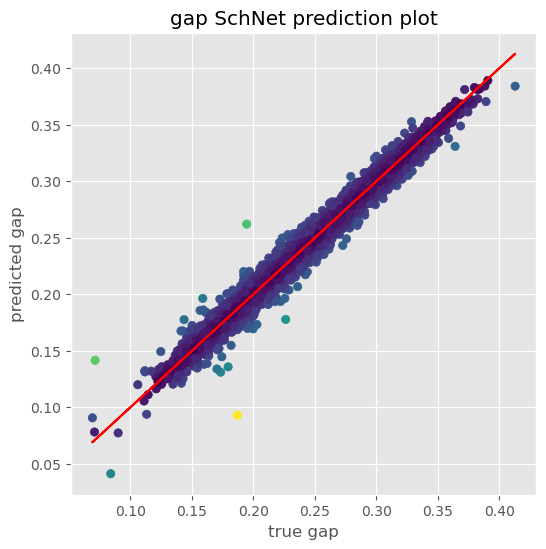

Training scores:
MAE = 0.0043
MSE = 0.0000
RMSE = 0.0059
r^2 = 0.9848


In [19]:
plot_prediction(val_loader, model, save='models/schnet/schnet_gap_qm9_plot_2.pdf')

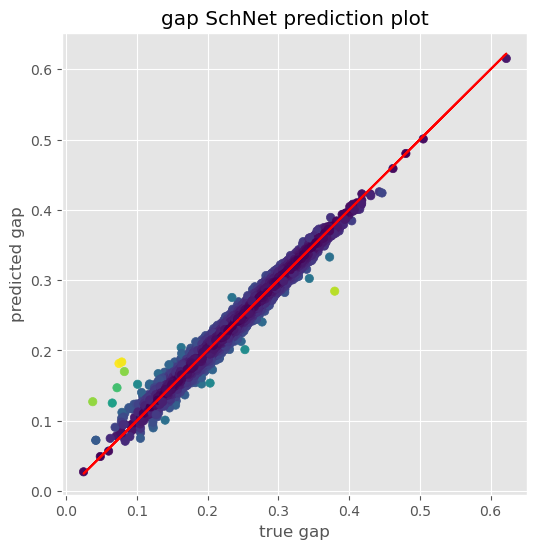

Training scores:
MAE = 0.0038
MSE = 0.0000
RMSE = 0.0051
r^2 = 0.9885


In [20]:
plot_prediction(train_loader, model)